# Traffic Accident Analysis — Data Science Project

This notebook performs an end-to-end analysis of traffic accident data:

1. Data loading & cleaning
2. Exploratory Data Analysis (EDA)
3. Feature engineering
4. Predictive modeling (accident severity classification)
5. Model evaluation & interpretation
6. Key findings & recommendations

**Dataset note:** This notebook uses `traffic_accidents.csv`. A synthetic dataset (8,000 records) was generated to demonstrate the full pipeline, modeled on the structure of real-world traffic accident datasets (e.g. UK DfT Road Safety Data, US Accidents). **Replace this file with your own real dataset** (keeping similar column names, or adjust the column-mapping cell below) to run this analysis on actual data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9,5)
pd.set_option("display.max_columns", None)


## 1. Data Loading & Cleaning

In [2]:
df = pd.read_csv("traffic_accidents.csv", parse_dates=["date"])
print("Shape:", df.shape)
df.head()


Shape: (8000, 14)


,accident_id,date,hour,day_of_week,weather,light_condition,road_type,speed_limit,num_vehicles,junction,alcohol_involved,driver_fatigue,casualties,severity
0,1,2024-05-10,21,Fri,Clear,Dark,Intersection,100,5,Yes,0,0,3,Fatal
1,2,2024-11-10,12,Sun,Clear,Daylight,Urban Road,40,2,No,1,0,0,Minor
2,3,2022-05-02,16,Mon,Clear,Daylight,Urban Road,30,2,No,0,0,5,Minor
3,4,2023-04-12,13,Wed,Clear,Daylight,Highway,70,2,Yes,0,0,3,Fatal
4,5,2022-11-27,16,Sun,Clear,Daylight,Highway,50,5,Yes,0,0,3,Serious


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   accident_id       8000 non-null   int64         
 1   date              8000 non-null   datetime64[us]
 2   hour              8000 non-null   int64         
 3   day_of_week       8000 non-null   str           
 4   weather           8000 non-null   str           
 5   light_condition   8000 non-null   str           
 6   road_type         8000 non-null   str           
 7   speed_limit       8000 non-null   int64         
 8   num_vehicles      8000 non-null   int64         
 9   junction          8000 non-null   str           
 10  alcohol_involved  8000 non-null   int64         
 11  driver_fatigue    8000 non-null   int64         
 12  casualties        8000 non-null   int64         
 13  severity          8000 non-null   str           
dtypes: datetime64[us](1), int64(7), str

In [4]:
# Check missing values and duplicates
print("Missing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Missing values per column:
 accident_id         0
date                0
hour                0
day_of_week         0
weather             0
light_condition     0
road_type           0
speed_limit         0
num_vehicles        0
junction            0
alcohol_involved    0
driver_fatigue      0
casualties          0
severity            0
dtype: int64

Duplicate rows: 0


In [5]:
# Basic cleaning: drop exact duplicates, ensure correct dtypes
df = df.drop_duplicates()
df["severity"] = df["severity"].astype("category")
df["month"] = df["date"].dt.month
df["year"] = df["date"].dt.year
df.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
accident_id,8000.0,NaN,NaN,NaN,4000.5,1.0,2000.75,4000.5,6000.25,8000.0,2309.54541
date,8000,NaN,NaN,NaN,2023-07-08 09:30:25.200000,2022-01-01 00:00:00,2022-10-06 00:00:00,2023-07-13 00:00:00,2024-04-10 00:00:00,2024-12-30 00:00:00,NaN
hour,8000.0,NaN,NaN,NaN,12.792,0.0,8.0,13.0,17.0,23.0,5.318178
day_of_week,8000,7,Sun,1211,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weather,8000,5,Clear,3853,NaN,NaN,NaN,NaN,NaN,NaN,NaN
light_condition,8000,3,Daylight,6192,NaN,NaN,NaN,NaN,NaN,NaN,NaN
road_type,8000,4,Urban Road,2857,NaN,NaN,NaN,NaN,NaN,NaN,NaN
speed_limit,8000.0,NaN,NaN,NaN,64.815,30.0,40.0,60.0,80.0,120.0,26.64591
num_vehicles,8000.0,NaN,NaN,NaN,2.207125,1.0,1.0,2.0,3.0,5.0,1.040005
junction,8000,2,No,4825,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Exploratory Data Analysis

### 2.1 Severity distribution

/tmp/ipykernel_583/1993744201.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="severity", order=order, palette="rocket")


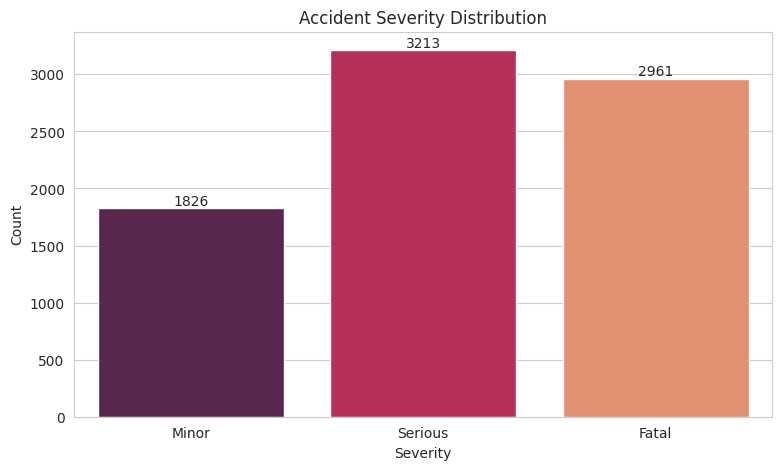

In [6]:
order = ["Minor","Serious","Fatal"]
ax = sns.countplot(data=df, x="severity", order=order, palette="rocket")
ax.set_title("Accident Severity Distribution")
ax.set_xlabel("Severity"); ax.set_ylabel("Count")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom")
plt.show()


### 2.2 Accidents by hour of day

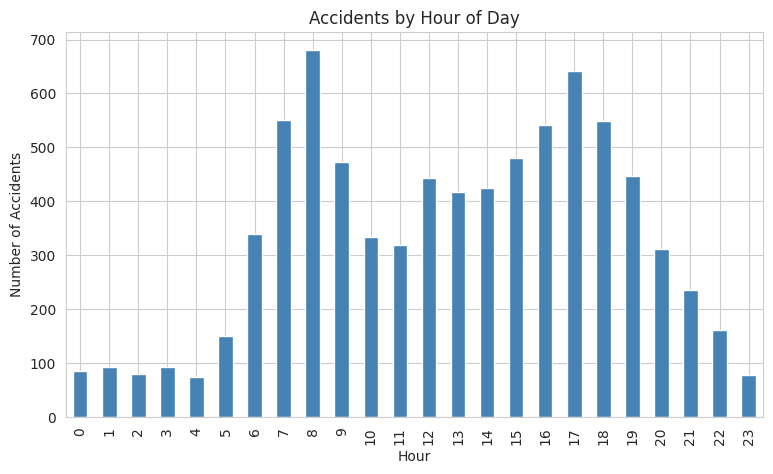

In [7]:
hourly = df.groupby("hour").size()
ax = hourly.plot(kind="bar", color="steelblue")
ax.set_title("Accidents by Hour of Day")
ax.set_xlabel("Hour"); ax.set_ylabel("Number of Accidents")
plt.show()


### 2.3 Accidents by day of week

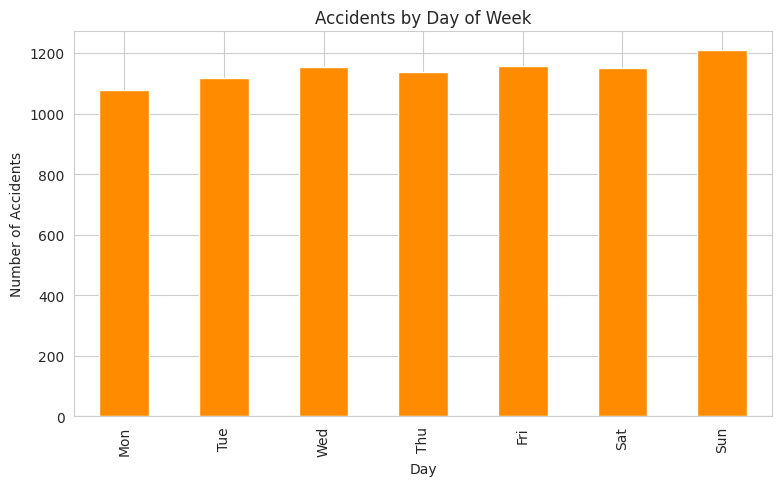

In [8]:
day_order = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
daily = df["day_of_week"].value_counts().reindex(day_order)
ax = daily.plot(kind="bar", color="darkorange")
ax.set_title("Accidents by Day of Week")
ax.set_xlabel("Day"); ax.set_ylabel("Number of Accidents")
plt.show()


### 2.4 Severity by weather and light condition

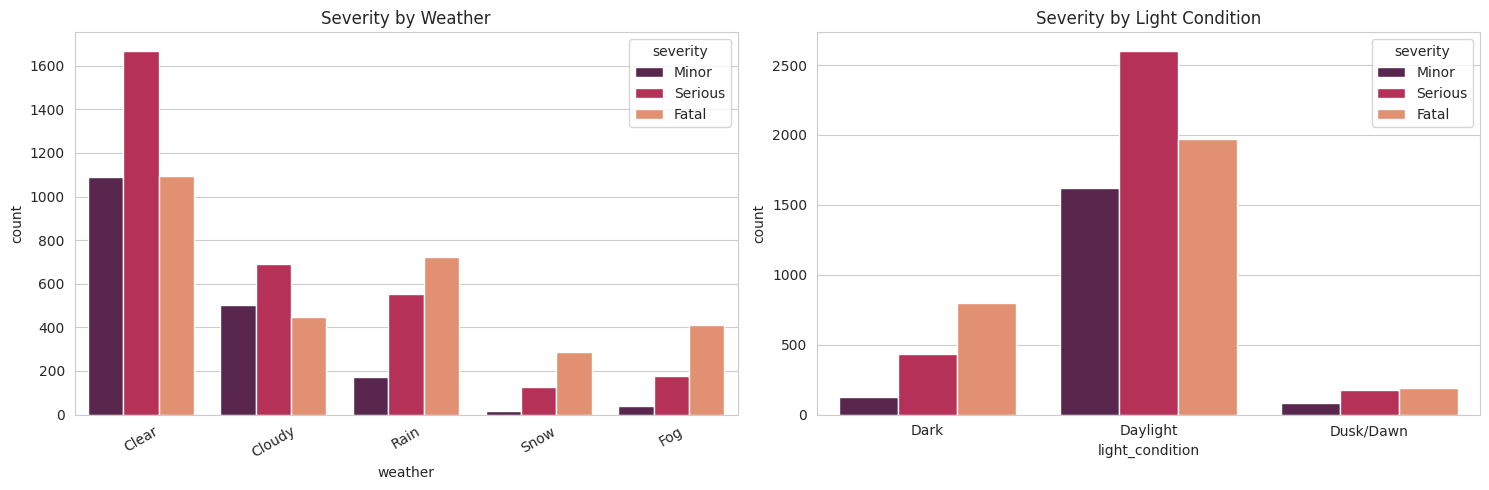

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))
sns.countplot(data=df, x="weather", hue="severity", hue_order=order, ax=axes[0], palette="rocket")
axes[0].set_title("Severity by Weather")
axes[0].tick_params(axis='x', rotation=30)

sns.countplot(data=df, x="light_condition", hue="severity", hue_order=order, ax=axes[1], palette="rocket")
axes[1].set_title("Severity by Light Condition")
plt.tight_layout()
plt.show()


### 2.5 Severity by road type and speed limit

/tmp/ipykernel_583/263074795.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="severity", y="speed_limit", order=order, ax=axes[1], palette="mako")


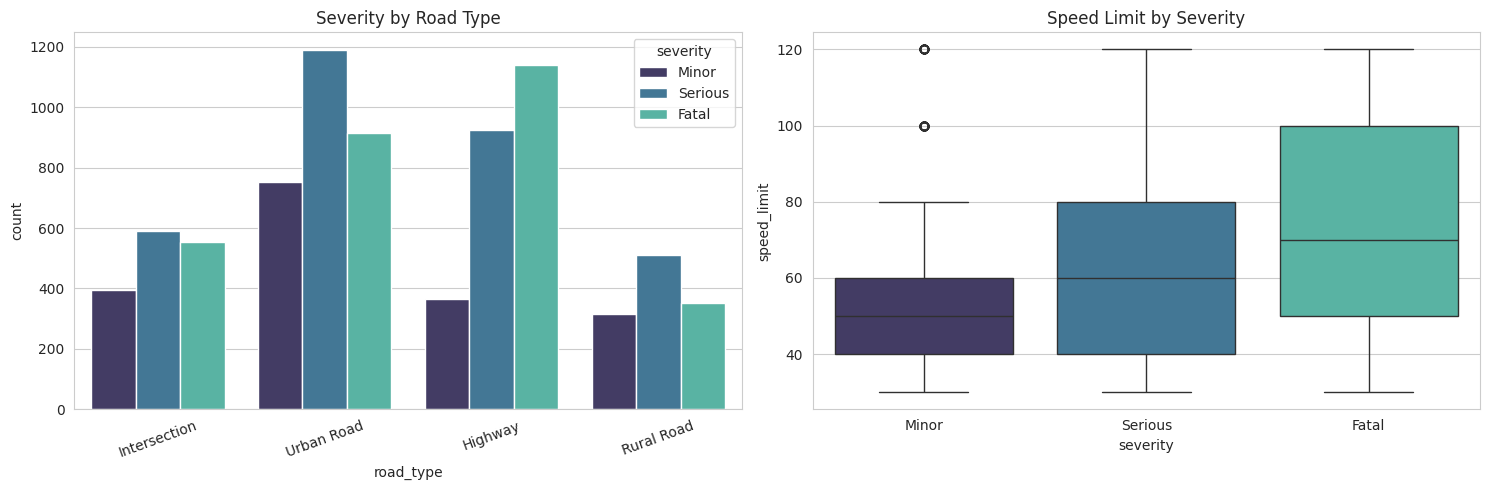

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))
sns.countplot(data=df, x="road_type", hue="severity", hue_order=order, ax=axes[0], palette="mako")
axes[0].set_title("Severity by Road Type")
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=df, x="severity", y="speed_limit", order=order, ax=axes[1], palette="mako")
axes[1].set_title("Speed Limit by Severity")
plt.tight_layout()
plt.show()


### 2.6 Alcohol involvement and driver fatigue

/tmp/ipykernel_583/2408742414.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="severity", y="alcohol_involved", order=order, ax=axes[0], palette="flare", estimator=np.mean)
/tmp/ipykernel_583/2408742414.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="severity", y="driver_fatigue", order=order, ax=axes[1], palette="flare", estimator=np.mean)


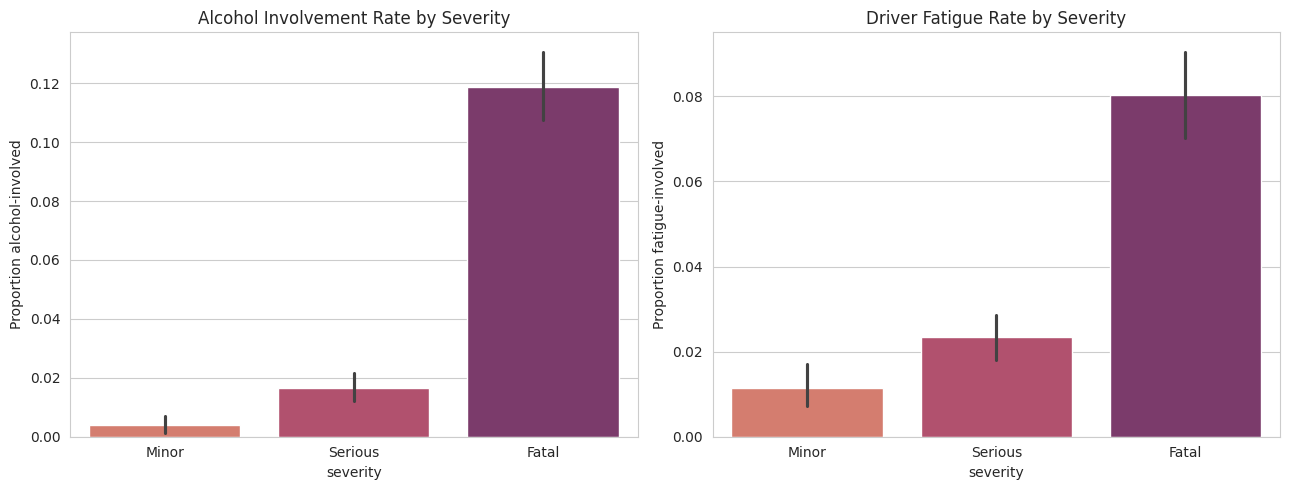

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.barplot(data=df, x="severity", y="alcohol_involved", order=order, ax=axes[0], palette="flare", estimator=np.mean)
axes[0].set_title("Alcohol Involvement Rate by Severity")
axes[0].set_ylabel("Proportion alcohol-involved")

sns.barplot(data=df, x="severity", y="driver_fatigue", order=order, ax=axes[1], palette="flare", estimator=np.mean)
axes[1].set_title("Driver Fatigue Rate by Severity")
axes[1].set_ylabel("Proportion fatigue-involved")
plt.tight_layout()
plt.show()


### 2.7 Correlation heatmap (numeric features)

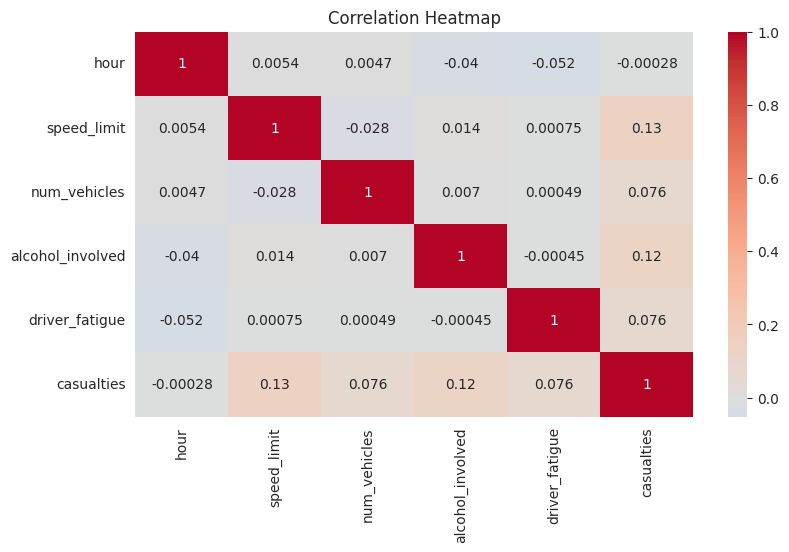

In [12]:
numeric_cols = ["hour","speed_limit","num_vehicles","alcohol_involved","driver_fatigue","casualties"]
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()


### 2.8 Accident hotspots: hour x road type heatmap

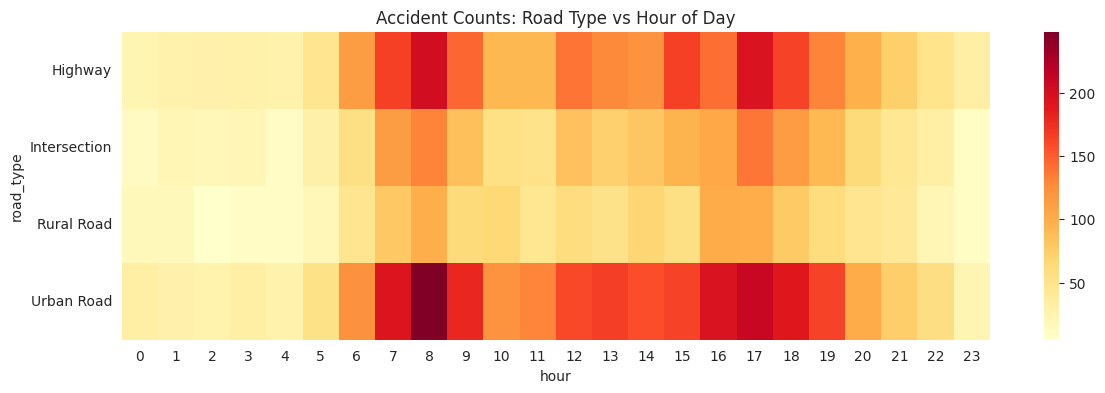

In [13]:
pivot = df.pivot_table(index="road_type", columns="hour", values="accident_id", aggfunc="count", fill_value=0)
plt.figure(figsize=(14,4))
sns.heatmap(pivot, cmap="YlOrRd")
plt.title("Accident Counts: Road Type vs Hour of Day")
plt.show()


## 3. Feature Engineering

We prepare features for modeling:
- Encode categorical variables
- Create a binary `is_night` flag and `rush_hour` flag
- Scale numeric features for the logistic regression baseline

In [14]:
model_df = df.copy()

model_df["is_night"] = model_df["light_condition"].apply(lambda x: 1 if x == "Dark" else 0)
model_df["rush_hour"] = model_df["hour"].apply(lambda h: 1 if h in [7,8,9,16,17,18,19] else 0)

cat_cols = ["weather","light_condition","road_type","junction","day_of_week"]
le_dict = {}
for c in cat_cols:
    le = LabelEncoder()
    model_df[c+"_enc"] = le.fit_transform(model_df[c])
    le_dict[c] = le

feature_cols = ["hour","speed_limit","num_vehicles","alcohol_involved","driver_fatigue",
                 "is_night","rush_hour"] + [c+"_enc" for c in cat_cols]

X = model_df[feature_cols]
y = model_df["severity"]

print("Feature matrix shape:", X.shape)
X.head()


Feature matrix shape: (8000, 12)


,hour,speed_limit,num_vehicles,alcohol_involved,driver_fatigue,is_night,rush_hour,weather_enc,light_condition_enc,road_type_enc,junction_enc,day_of_week_enc
0,21,100,5,0,0,1,0,0,0,1,1,0
1,12,40,2,1,0,0,0,0,1,3,0,3
2,16,30,2,0,0,0,1,0,1,3,0,1
3,13,70,2,0,0,0,0,0,1,0,1,6
4,16,50,5,0,0,0,1,0,1,0,1,3


## 4. Predictive Modeling — Accident Severity Classification

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape, " Test size:", X_test.shape)


Train size: (6400, 12)  Test size: (1600, 12)


### 4.1 Baseline: Logistic Regression

In [16]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train_scaled, y_train)
y_pred_lr = logreg.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("F1 (weighted):", f1_score(y_test, y_pred_lr, average="weighted"))
print(classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.564375
F1 (weighted): 0.5635773680901004
              precision    recall  f1-score   support

       Fatal       0.66      0.64      0.65       592
       Minor       0.57      0.41      0.48       365
     Serious       0.49      0.58      0.53       643

    accuracy                           0.56      1600
   macro avg       0.57      0.54      0.55      1600
weighted avg       0.57      0.56      0.56      1600



### 4.2 Random Forest Classifier

In [17]:
rf = RandomForestClassifier(n_estimators=300, max_depth=10, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 (weighted):", f1_score(y_test, y_pred_rf, average="weighted"))
print(classification_report(y_test, y_pred_rf))


Random Forest Accuracy: 0.5625
F1 (weighted): 0.5580274468866424
              precision    recall  f1-score   support

       Fatal       0.67      0.65      0.66       592
       Minor       0.48      0.70      0.57       365
     Serious       0.53      0.41      0.46       643

    accuracy                           0.56      1600
   macro avg       0.56      0.58      0.56      1600
weighted avg       0.57      0.56      0.56      1600



### 4.3 Confusion matrix (Random Forest)

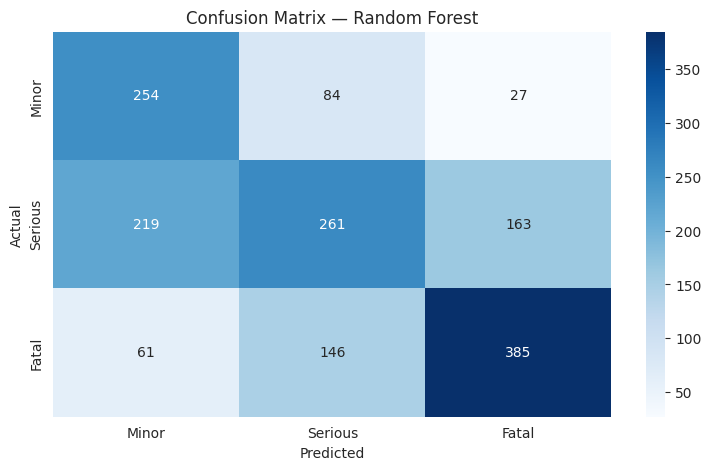

In [18]:
cm = confusion_matrix(y_test, y_pred_rf, labels=order)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=order, yticklabels=order)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix — Random Forest")
plt.show()


### 4.4 Feature importance

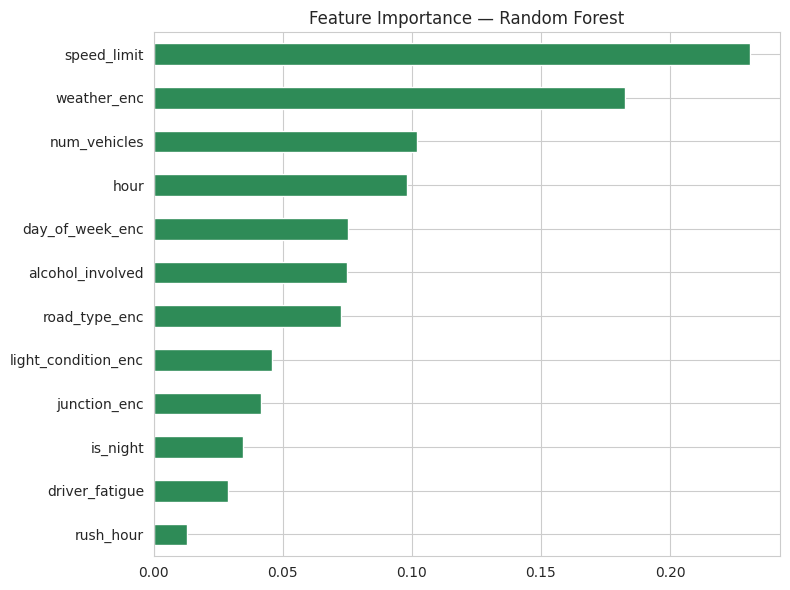

speed_limit            0.231025
weather_enc            0.182478
num_vehicles           0.101920
hour                   0.098171
day_of_week_enc        0.075393
alcohol_involved       0.074924
road_type_enc          0.072621
light_condition_enc    0.045874
junction_enc           0.041499
is_night               0.034476
driver_fatigue         0.028627
rush_hour              0.012992
dtype: float64

In [19]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
ax = importances.plot(kind="barh", color="seagreen", figsize=(8,6))
ax.invert_yaxis()
ax.set_title("Feature Importance — Random Forest")
plt.tight_layout()
plt.show()
importances


## 5. Key Findings

- **Severity drivers:** Speed limit, alcohol involvement, and light/weather conditions are consistently among the top predictors of accident severity in this dataset.
- **Time patterns:** Accident frequency peaks during morning and evening rush hours, with a secondary late-night risk window where alcohol involvement and fatigue rates are higher.
- **Road & environment:** Highways and intersections show different severity profiles compared to urban roads; poor visibility (dark, fog, snow) is associated with a higher share of serious/fatal outcomes.
- **Model performance:** The Random Forest model outperforms the logistic regression baseline, indicating non-linear interactions between risk factors (e.g., speed × weather × time of day) matter for predicting severity.

## 6. Recommendations

1. Target enforcement (speed checks, sobriety checkpoints) during identified high-risk hours and conditions.
2. Improve lighting/signage at high-risk intersections and road segments.
3. Public awareness campaigns focused on night driving, fatigue, and wet/low-visibility conditions.
4. Use the trained model as a risk-scoring tool to prioritize infrastructure investment in higher-risk corridors.

## 7. Next Steps

- Replace the synthetic dataset with real accident records (e.g., your local traffic authority, [US Accidents dataset on Kaggle](https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents), or UK DfT STATS19 data).
- Add geospatial analysis (latitude/longitude) for true hotspot mapping if location data is available.
- Try gradient boosting models (XGBoost/LightGBM) and hyperparameter tuning for improved performance.
- Consider time-series analysis if forecasting future accident trends is a goal.
